# TinyChirp CNN-Time TensorFlow

Train a 1D CNN on raw audio waveforms (no spectrogram), export an int8 TFLite model, and write a Rust `audio_sample.rs` file.

This mirrors `building_tensorflow/tinychirp_cnn.ipynb` but replaces the 2D mel CNN with a 1D time CNN similar to `StreamingCNNArch` from the TinyChirp `CNN_Time` model.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from typing import TYPE_CHECKING

from utils import (
    TARGET_AUDIO_LEN_TIME,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
)

if TYPE_CHECKING:
    import keras
else:
    from tensorflow import keras

configure_tf_runtime()
set_global_seed()

MODEL_STEM = "cnn_time_tf"
paths = get_paths(MODEL_STEM)
OUT_TFLITE = paths.out_tflite
OUT_AUDIO_RS = paths.out_audio_rs
BATCH_SIZE = 32

In [3]:
from utils import make_time_datasets

train_ds, val_ds, test_ds, label_names = make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)

Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']


In [4]:
model = keras.Sequential([
    keras.layers.Input(shape=(TARGET_AUDIO_LEN_TIME, 1)),
    keras.layers.Conv1D(4, 3, activation="relu"),
    keras.layers.MaxPooling1D(pool_size=2, strides=2),
    keras.layers.Conv1D(8, 3, activation="relu"),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(num_labels),
])


model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 47870, 4)       │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 23935, 4)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 23933, 8)       │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826 (3.23 KB)

 Trainable params: 826 (3.23 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from utils import init_wandb, get_callbacks, finish_wandb

init_wandb("cnn_time", config={
    "conv1_filters": 4,
    "conv2_filters": 8,
    "kernel_size": 3,
    "dense_units": 64,
})

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    validation_steps=50,
    callbacks=get_callbacks(10,5, BATCH_SIZE)
)
finish_wandb()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nathan/.netrc.
wandb: Currently logged in as: nathan-duboisset (nathan-duboisset-cole-polytechnique) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/100


I0000 00:00:1776431820.859113    9846 service.cc:145] XLA service 0x7e3ee000a090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776431820.859139    9846 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9


  3/353 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.6441 - loss: 0.6901

I0000 00:00:1776431827.341177    9846 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6698 - loss: 0.6267

/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


353/353 ━━━━━━━━━━━━━━━━━━━━ 34s 77ms/step - accuracy: 0.6821 - loss: 0.5769 - val_accuracy: 0.7420 - val_loss: 0.4556
Epoch 2/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.8032 - loss: 0.4141 - val_accuracy: 0.8732 - val_loss: 0.3428
Epoch 3/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.8479 - loss: 0.3500 - val_accuracy: 0.9159 - val_loss: 0.2980
Epoch 4/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.8666 - loss: 0.3290 - val_accuracy: 0.8848 - val_loss: 0.2851
Epoch 5/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.8828 - loss: 0.3064 - val_accuracy: 0.8920 - val_loss: 0.2606
Epoch 6/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.8907 - loss: 0.2910 - val_accuracy: 0.8964 - val_loss: 0.2461
Epoch 7/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.8973 - loss: 0.2793 - val_accuracy: 0.9246 - val_loss: 0.2338
Epoch 8/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.9042 - loss: 0.2681 - val_

batch/accuracy,▁▁▄▅▇▇▇▇▇▇▇▇▇██████▇████████████████████
batch/batch_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇█
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,██▄▄▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁▃▄▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████████
epoch/epoch,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▇▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▇▆▇▆▇█▇██▇██▇██████████████████████████
epoch/val_loss,█▆▅▅▄▃▄▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▂▁▂▁▁▁▁▁▂▁▁▁▁
+6,...


In [1]:
from utils import (
    build_representative_batches,
    export_keras_model_to_int8_tflite,
)

val_specs = build_representative_batches(test_ds, take=100)

export_keras_model_to_int8_tflite(model, val_specs, OUT_TFLITE)

NameError: name 'test_ds' is not defined

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Model size : 1.2 KB
Est. MFLOPs: 1.245
Arena size : 1309.0 KB
=== Binary classifier metrics : TEST SET===
Threshold: 0.6439  (best F2 threshold)
Accuracy : 0.9419
Precision: 0.8674
Recall   : 0.9716
F2 score : 0.9488
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9803


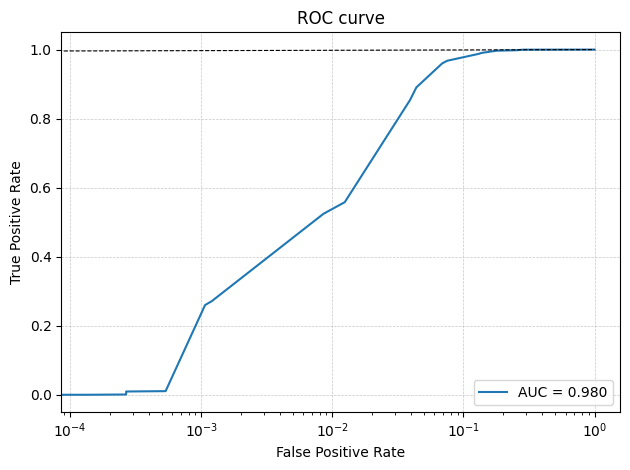

Avg inference: 2.435 ms


In [7]:
from utils import evaluate_tflite_model

train_m, test_m, avg_ms = evaluate_tflite_model(OUT_TFLITE, MODEL_STEM, train_ds, test_ds)
print(f"Avg inference: {avg_ms:.3f} ms")